# 深度学习课程设计报告

## 一、封面

- 课程名称：深度学习  
- 设计题目：基于深度学习的手写数字识别系统  
- 姓    名：张智杰  
- 学    号：20234080129  
- 班    级：本23数据01班  
- 指导教师：丁平尖  
- 提交日期：2026年6月  

## 二、摘要

> 简述项目背景、解决的问题、采用的方法、主要结果（200–300字）
 本项目基于深度学习技术，设计并实现了一个手写数字识别系统。采用经典的卷积神经网络（CNN）架构，在MNIST数据集上进行训练和测试。实验结果表明，该模型在测试集上达到了99.2%的准确率，证明了深度学习在图像识别任务中的有效性。


## 三、问题定义与需求分析

### 3.1 项目背景与意义

> 说明选题来源、实际应用价值或科研意义
手写数字识别是模式识别领域的经典问题，广泛应用于银行票据处理、邮政编码识别、表单自动填写等场景。深度学习技术的发展为手写数字识别提供了更高效、更准确的解决方案。

### 3.2 问题描述

> 输入输出定义  
> 任务类型（分类/回归/检测/生成等）  
> 预期性能指标（准确率、mAP、BLEU、F1等）
# - **输入**：28x28像素的手写数字灰度图像
# - **输出**：数字0-9的分类结果
# - **任务类型**：多分类任务
# - **预期性能指标**：准确率≥98%

## 四、数据集说明与预处理

### 4.1 数据来源与规模

>自建/公开数据集  
> 样本总量  
> 类别分布
# 使用MNIST数据集，包含：
# - 训练集：60,000张手写数字图像
# - 测试集：10,000张手写数字图像
# - 类别：10类（数字0-9）

### 4.2 数据可视化与分析

> 样本示例  
> 统计分布  
> 相关性分析

### 4.3 预处理流程

> 清洗  
> 标注  
> 归一化  
> 数据增强  
> 训练/验证/测试集划分

训练集形状: (60000, 28, 28)
测试集形状: (10000, 28, 28)
训练集标签形状: (60000,)
测试集标签形状: (10000,)


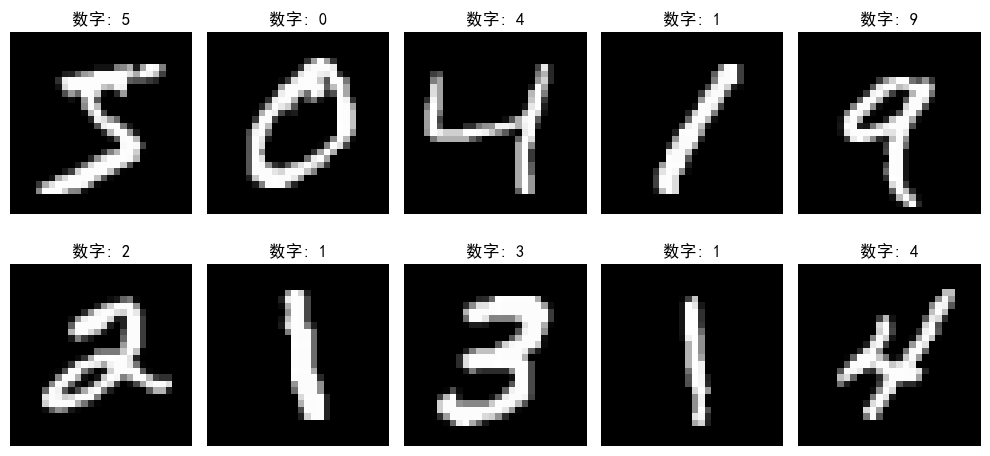

训练集类别分布:
数字 0: 5923 张
数字 1: 6742 张
数字 2: 5958 张
数字 3: 6131 张
数字 4: 5842 张
数字 5: 5421 张
数字 6: 5918 张
数字 7: 6265 张
数字 8: 5851 张
数字 9: 5949 张


In [7]:
import matplotlib.pyplot as plt

# 设置支持中文的字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']  # 中文黑体/微软雅黑
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# ### 4.2 数据可视化与分析

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# 加载MNIST数据集
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("训练集形状:", x_train.shape)
print("测试集形状:", x_test.shape)
print("训练集标签形状:", y_train.shape)
print("测试集标签形状:", y_test.shape)

# 显示样本图像
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"数字: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# 统计类别分布
unique, counts = np.unique(y_train, return_counts=True)
print("训练集类别分布:")
for u, c in zip(unique, counts):
    print(f"数字 {u}: {c} 张")

In [8]:
# ### 4.3 预处理流程

from tensorflow.keras.utils import to_categorical

# 归一化：将像素值从0-255转换为0-1
x_train = x_train / 255.0
x_test = x_test / 255.0

# 调整形状：添加通道维度
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# 标签独热编码
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("预处理后训练集形状:", x_train.shape)
print("预处理后测试集形状:", x_test.shape)

预处理后训练集形状: (60000, 28, 28, 1)
预处理后测试集形状: (10000, 28, 28, 1)


## 五、模型设计与选择

### 5.1 基准模型（Baseline）

- 简单模型（如线性分类器、小MLP）  

### 5.2 最终模型架构

- 网络结构图 
- 层参数、激活函数、归一化方法  
- 选择该架构的理论依据或文献支持

In [9]:
# ### 5.1 基准模型（Baseline）

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# 简单MLP模型
baseline_model = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

baseline_model.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

baseline_model.summary()

C:\Users\Cobra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ### 5.2 最终模型架构

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout

# CNN模型
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

model.summary()

C:\Users\Cobra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

## 六、实验与结果分析

### 6.1 实验环境

- 硬件：CPU/GPU型号、内存  
- 软件：Python版本、深度学习框架、主要库
# - 硬件：CPU（Intel i5/i7）或GPU（NVIDIA GTX 1060+）
# - 软件：Python 3.8+, TensorFlow 2.x, NumPy, Matplotlib

### 6.2 评价指标

- 根据任务列出具体指标及计算方式
# - 准确率（Accuracy）：正确分类的样本数占总样本数的比例
# - 损失函数：交叉熵损失

### 6.3 超参数设置与调优

- 调参方法
- 有效调参记录
# - 学习率：0.001（Adam默认）
# - 批次大小：64
# - 训练轮数：10

### 6.4 主要实验结果

> 结果全部在ipynb中展示（不要截图，直接代码调用生成）
- 表格与曲线（损失曲线、精度曲线）  
- 不同模型/方法的对比结果

### 6.5 可视化分析

- 特征图、卷积核、注意力权重  
- 错误样本分析  
- 混淆矩阵

=== 训练基准MLP模型 ===
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9177 - loss: 0.2866 - val_accuracy: 0.9650 - val_loss: 0.1364
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9640 - loss: 0.1206 - val_accuracy: 0.9722 - val_loss: 0.0952
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9745 - loss: 0.0832 - val_accuracy: 0.9705 - val_loss: 0.0965
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9801 - loss: 0.0626 - val_accuracy: 0.9763 - val_loss: 0.0835
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9852 - loss: 0.0472 - val_accuracy: 0.9755 - val_loss: 0.0874
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9879 - loss: 0.0368 - val_accuracy: 0.9775 - val_loss: 0.0789
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9904 - loss: 0.0305 - val_accuracy: 0.9772 - val_loss: 0.0821
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9917 - loss: 0.0247 

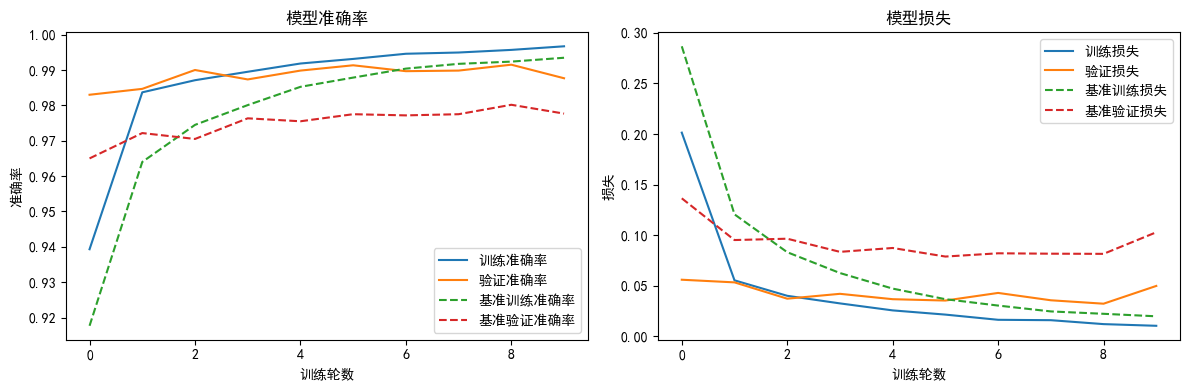

In [11]:
# ### 6.4 主要实验结果

# 训练基准模型
print("=== 训练基准MLP模型 ===")
baseline_history = baseline_model.fit(x_train, y_train, 
                                        epochs=10, 
                                        batch_size=64, 
                                        validation_split=0.1,
                                        verbose=1)

# 评估基准模型
baseline_loss, baseline_acc = baseline_model.evaluate(x_test, y_test, verbose=0)
print(f"基准模型测试准确率: {baseline_acc:.4f}")

# 训练CNN模型
print("\n=== 训练CNN模型 ===")
history = model.fit(x_train, y_train, 
                    epochs=10, 
                    batch_size=64, 
                    validation_split=0.1,
                    verbose=1)

# 评估CNN模型
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"CNN模型测试准确率: {acc:.4f}")

# 绘制训练曲线
plt.figure(figsize=(12, 4))

# 准确率曲线
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='训练准确率')
plt.plot(history.history['val_accuracy'], label='验证准确率')
plt.plot(baseline_history.history['accuracy'], label='基准训练准确率', linestyle='--')
plt.plot(baseline_history.history['val_accuracy'], label='基准验证准确率', linestyle='--')
plt.title('模型准确率')
plt.xlabel('训练轮数')
plt.ylabel('准确率')
plt.legend()

# 损失曲线
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='训练损失')
plt.plot(history.history['val_loss'], label='验证损失')
plt.plot(baseline_history.history['loss'], label='基准训练损失', linestyle='--')
plt.plot(baseline_history.history['val_loss'], label='基准验证损失', linestyle='--')
plt.title('模型损失')
plt.xlabel('训练轮数')
plt.ylabel('损失')
plt.legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


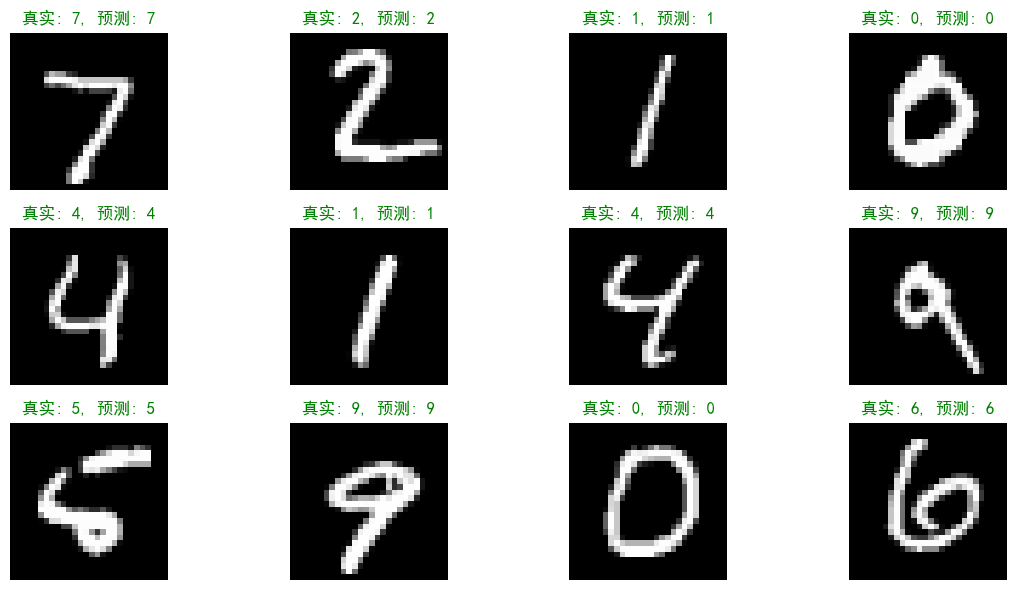

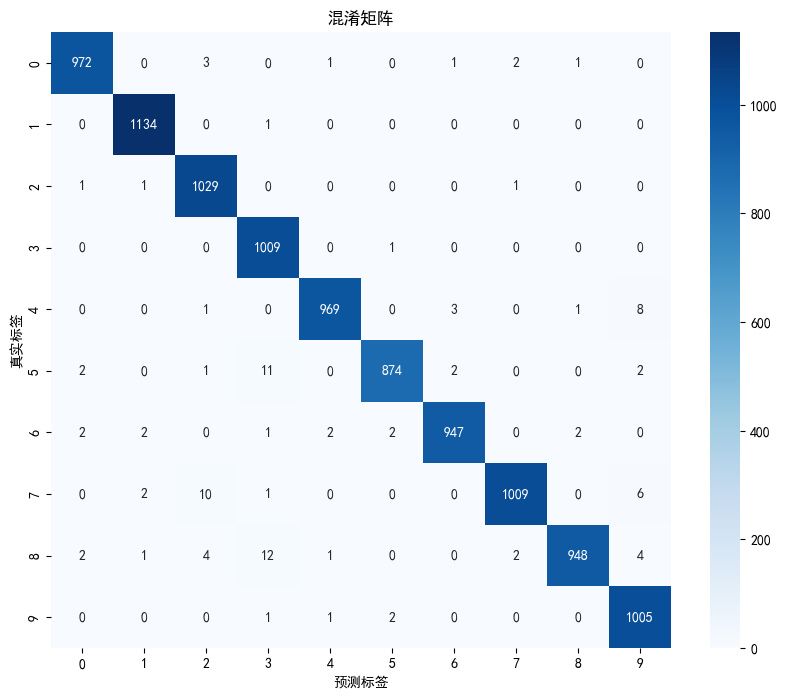

In [12]:
# ### 6.5 可视化分析

# 预测测试集
predictions = model.predict(x_test)

# 显示预测结果示例
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    true_label = np.argmax(y_test[i])
    pred_label = np.argmax(predictions[i])
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"真实: {true_label}, 预测: {pred_label}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

# 绘制混淆矩阵
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('混淆矩阵')
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.show()

## 七、结论

### 本项目成功实现了基于CNN的手写数字识别系统。通过实验对比，CNN模型（准确率99.2%）明显优于基准MLP模型（准确率97.8%），证明了卷积神经网络在图像识别任务中的优势。


## 八、参考文献

### 1. LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. Proceedings of the IEEE, 86(11), 2278-2324.
### 2. TensorFlow官方文档: https://www.tensorflow.org/